In [10]:
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import xclimate as xclim

In [2]:
def compute_annual_mean(da):
    days_in_month = da.time.dt.days_in_month
    weights = days_in_month.groupby('time.year') / days_in_month.groupby('time.year').sum()
    return (da * weights).groupby('time.year').sum()

In [46]:
best_tas = xr.open_dataset("/glade/work/bbuchovecky/data/best/best_global_land_surface_tavg.nc").tavg_absolute
best_annual_tas_land = compute_annual_mean(best_tas).compute()

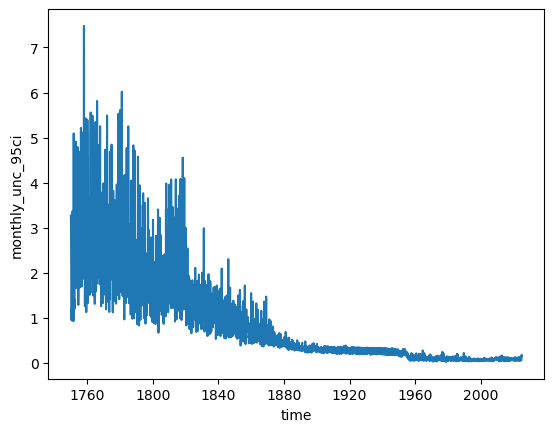

In [34]:
best_tas.monthly_unc_95ci.plot()

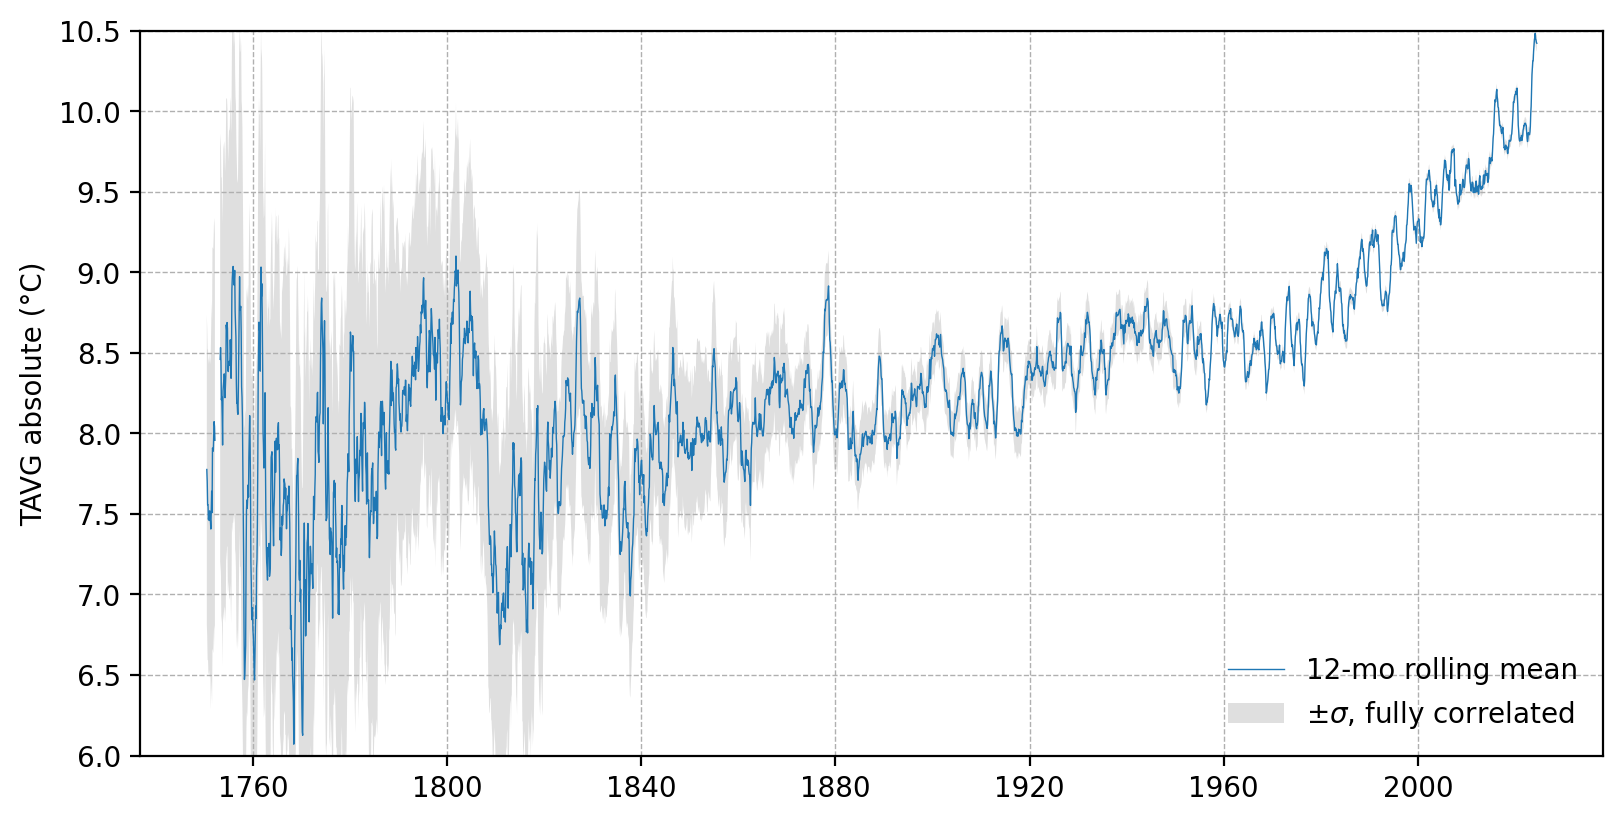

In [44]:
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained', dpi=200)

# best_tas.rolling(time=12, center=True).mean().plot(ax=ax, lw=0.5)
# best_tas.rolling(time=12*10, center=True).mean().plot(ax=ax, c='red', lw=1)

sigma = best_tas["monthly_unc_95ci"] / 1.96  # 95% CI -> approx standard error

# Lower bound: independent errors
var_indep = (sigma ** 2).rolling(time=12, center=True).sum() / 144
se_indep = np.sqrt(var_indep)

# Upper bound: fully correlated errors within each 12-month window
se_corr = sigma.rolling(time=12, center=True).mean()

roll_mean = best_tas.rolling(time=12, center=True).mean()

ax.plot(best_tas["time"], roll_mean, linewidth=0.5, label="12-mo rolling mean")
ax.fill_between(best_tas["time"], roll_mean - se_corr, roll_mean + se_corr,
                 color="gray", alpha=0.25, label=r"$\pm\sigma$, fully correlated", lw=0)
# ax.fill_between(best_tas["time"], roll_mean - se_indep, roll_mean + se_indep,
#                  color="steelblue", alpha=0.3, label=r"$\pm\sigma$, independent", lw=0)
ax.set_ylabel("TAVG absolute (°C)")
ax.legend(frameon=False)

ax.set_ylim(6, 10.5)
ax.set_yticks(np.arange(6, 11, 0.5))
ax.grid(ls='--', lw=0.5)

In [3]:
era_grid = xclim.load_era5_grid()
era_tas = xclim.load_era5("2t", "1950", "2014") - 273.15
era_ann_tas = compute_annual_mean(era_tas)
era_ann_tas_global = era_ann_tas.weighted(era_grid.AREA).mean(dim=['lat', 'lon'])
era_ann_tas_land = era_ann_tas.weighted(era_grid.LANDAREA).mean(dim=['lat', 'lon'])
era_ann_tas_global_anom = era_ann_tas_global - era_ann_tas_global.sel(year=slice(1982, 2011)).mean(dim='year').compute()
era_ann_tas_land_anom = era_ann_tas_land - era_ann_tas_land.sel(year=slice(1982, 2011)).mean(dim='year').compute()

In [4]:
fhist_grid = xclim.load_fhist_ppe_grid()

v = 'TREFHT_month_1'
name = "_".join(v.split("_")[:-2])
fhist_tas = xclim.load_fhist(v, keep_var_only=True)[name].reindex_like(fhist_grid, method="nearest", tolerance=1e-3) - 273.15

fhist_ann_tas = compute_annual_mean(fhist_tas)
fhist_ann_tas_global = fhist_ann_tas.weighted(fhist_grid.AREA).mean(dim=['lat', 'lon']).compute()
fhist_ann_tas_land = fhist_ann_tas.weighted(fhist_grid.LANDAREA).mean(dim=['lat', 'lon']).compute()
fhist_ann_tas_global_anom = fhist_ann_tas_global - fhist_ann_tas_global.sel(year=slice(1982, 2011)).mean(dim='year')
fhist_ann_tas_land_anom = fhist_ann_tas_land - fhist_ann_tas_land.sel(year=slice(1982, 2011)).mean(dim='year')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


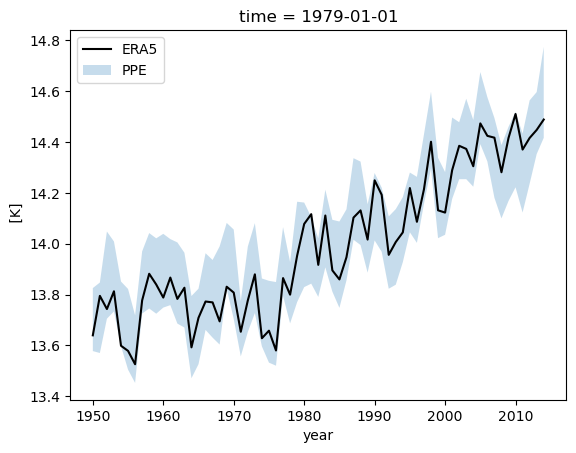

In [5]:
era_ann_tas_global.plot(c='k', label='ERA5')
plt.fill_between(
    fhist_ann_tas_global.year,
    fhist_ann_tas_global.min(dim='member'),
    fhist_ann_tas_global.max(dim='member'),
    facecolor='tab:blue',
    linewidth=0,
    alpha=0.25,
    label='PPE'
)
plt.legend()

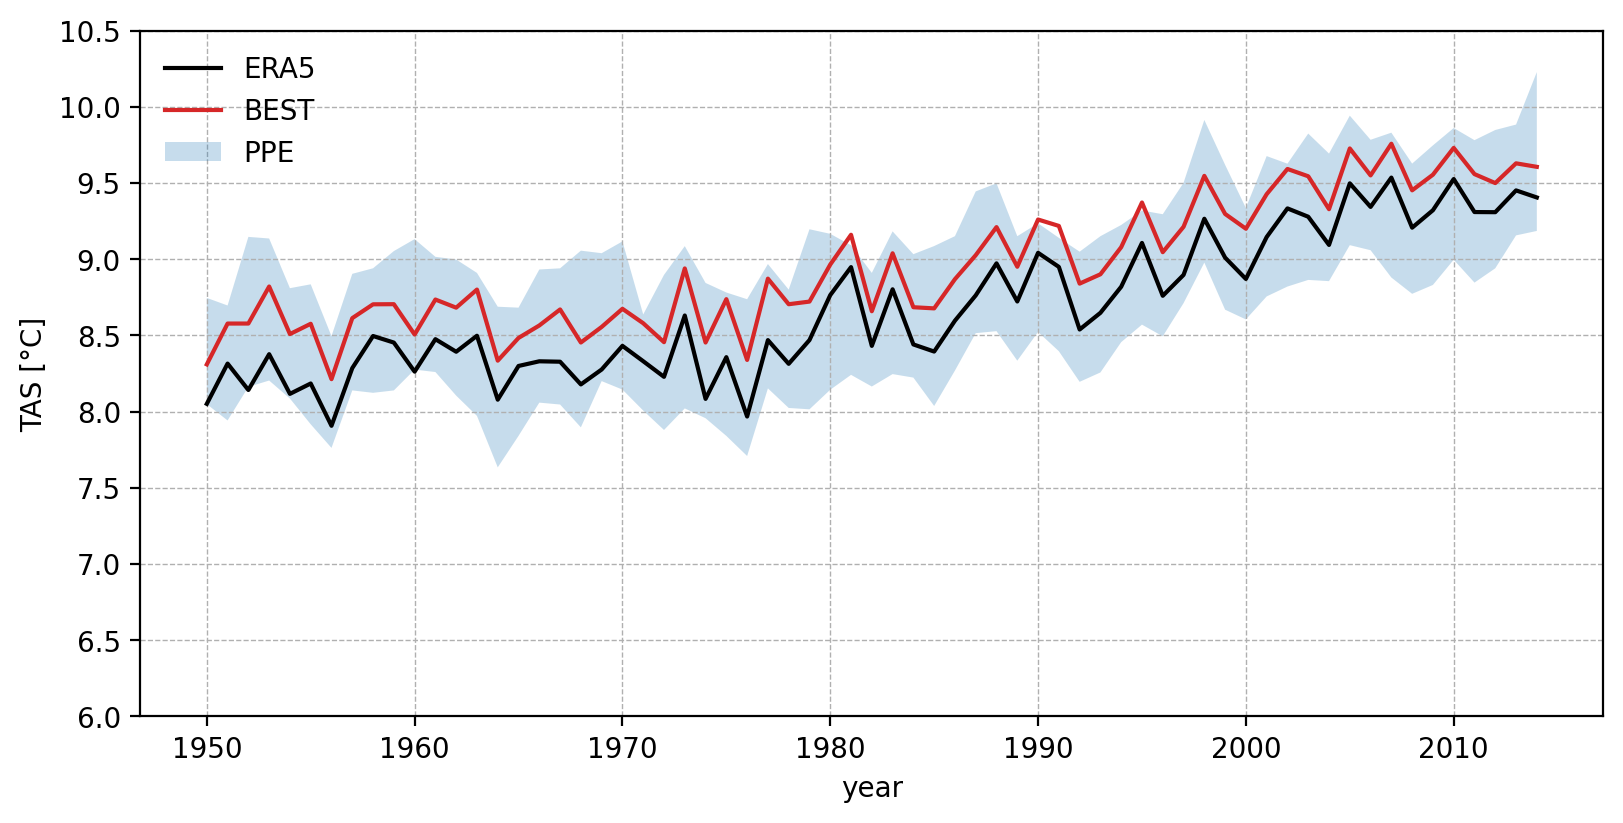

In [50]:
fig, ax = plt.subplots(figsize=(8, 4), layout='constrained', dpi=200)

era_ann_tas_land.plot(c='k', label='ERA5')
best_annual_tas_land.sel(year=slice(1950, 2014)).plot(ax=ax, color="tab:red", label="BEST")

ax.fill_between(
    fhist_ann_tas_land.year,
    fhist_ann_tas_land.min(dim='member'),
    fhist_ann_tas_land.max(dim='member'),
    facecolor='tab:blue',
    linewidth=0,
    alpha=0.25,
    label='PPE'
)

ax.set_ylabel("TAS [°C]")
ax.set_ylim(6, 10.5)
ax.set_yticks(np.arange(6, 11, 0.5))
ax.grid(ls='--', lw=0.5)
ax.legend(frameon=False)

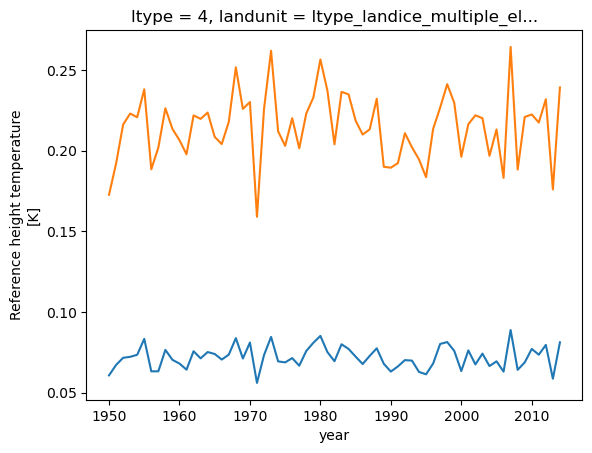

In [7]:
fhist_ann_tas_global.std(dim='member').plot()
fhist_ann_tas_land.std(dim='member').plot(c='tab:orange')

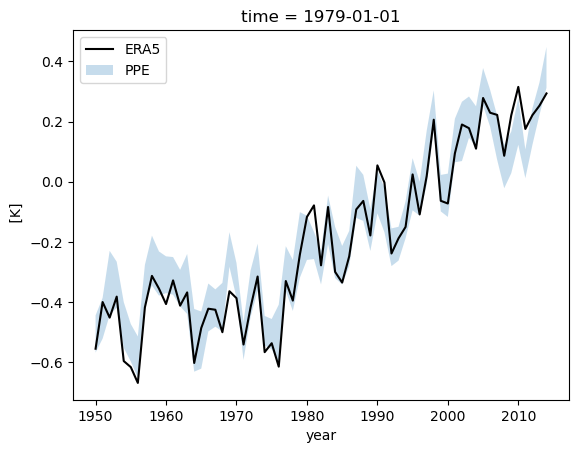

In [8]:
era_ann_tas_global_anom.plot(c='k', label='ERA5')
plt.fill_between(
    fhist_ann_tas_global_anom.year,
    fhist_ann_tas_global_anom.min(dim='member'),
    fhist_ann_tas_global_anom.max(dim='member'),
    facecolor='tab:blue',
    linewidth=0,
    alpha=0.25,
    label='PPE'
)
plt.legend()

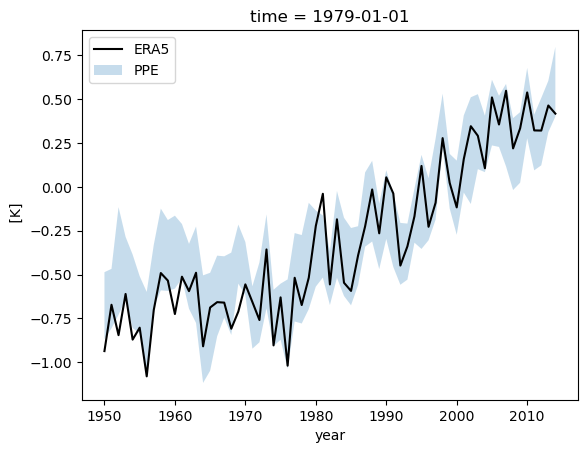

In [9]:
era_ann_tas_land_anom.plot(c='k', label='ERA5')
plt.fill_between(
    fhist_ann_tas_land_anom.year,
    fhist_ann_tas_land_anom.min(dim='member'),
    fhist_ann_tas_land_anom.max(dim='member'),
    facecolor='tab:blue',
    linewidth=0,
    alpha=0.25,
    label='PPE'
)
plt.legend()

In [2]:
area = xr.open_dataset("/glade/work/bbuchovecky/era5/e5.invariant.gridarea.nc").cell_area / 1e6
area.attrs['units'] = 'km^2'
area.attrs['method'] = 'cdo gridarea /gdex/data/d633000/e5.oper.invariant/197901/e5.oper.invariant.128_172_lsm.ll025sc.1979010100_1979010100.nc /glade/work/bbuchovecky/era5/e5.invariant.gridarea.nc'

lf = xr.open_dataset("/gdex/data/d633000/e5.oper.invariant/197901/e5.oper.invariant.128_172_lsm.ll025sc.1979010100_1979010100.nc").LSM.isel(time=0)

la = area * lf
la.attrs = {
    "long_name": "land area of grid box",
    "units": "km^2",
}

In [3]:
xr.Dataset(
    data_vars=dict(
        AREA=area,
        LANDAREA=la,
        LANDFRAC=lf,
    ),
).rename({'latitude': 'lat', 'longitude': 'lon'}).to_netcdf("/glade/work/bbuchovecky/era5/e5.invariant.grid.nc")